# Phase 5: Tuning parameters

In [1]:
import os
os.environ["R_HOME"] = "/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/R"


import os
import sim_unstructured as sim
from collections import Counter
import helper_functions as hf
import pandas as pd
import numpy as np
import quiche as qu
import scanpy as sc
import anndata as ad
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns


%reload_ext autoreload
%load_ext autoreload
%autoreload 2
%matplotlib inline

#sc.set_figure_params(dpi = 400, dpi_save = 400, fontsize = 14)
#sc.set_figure_params(dpi = 120, dpi_save = 300, fontsize = 14) # smaller plots for now

/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


To use sccoda or tasccoda please install ete3 with pip install ete3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Sim

In [2]:
cfg = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,
    prevalence=1.0,
    random_state=42,
    preserve_global_counts=True,
)

cells, meta = sim.simulate_cohort(cfg)
adata = hf.cells_to_adata(cells)

In [9]:
geometry_grid = [
    {"radius": 20, "n_neighbors": 20},
    {"radius": 20, "n_neighbors": 30},
    {"radius": 25, "n_neighbors": 20},
    {"radius": 25, "n_neighbors": 30},
    {"radius": 30, "n_neighbors": 20},
    {"radius": 30, "n_neighbors": 30},
    {"radius": 35, "n_neighbors": 20},
    {"radius": 35, "n_neighbors": 30},
]

downstream_grid = [
    {"k_sim": 50, "sketch_size": None},
    {"k_sim": 100, "sketch_size": None},
    #{"k_sim": 50, "sketch_size": 1000},
    #{"k_sim": 100, "sketch_size": 1000},
]

## Run Sweep

In [10]:
results = []

for g in geometry_grid:
    for d in downstream_grid:
        print(f"Running: {g}, {d}")

        q = hf.run_quiche_once(
            adata,
            radius=g["radius"],
            n_neighbors=g["n_neighbors"],
            k_sim=d["k_sim"],
            sketch_size=d["sketch_size"],
        )

        metrics = hf.compute_recovery_metrics(q)

        row = {
            **g,
            **d,
            **metrics,
        }

        results.append(row)

df_results = pd.DataFrame(results)

df_results.to_csv("phase_5_results_01.csv", index = False)

INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...


Running: {'radius': 20, 'n_neighbors': 20}, {'k_sim': 50, 'sketch_size': None}


INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99430/99430 [00:02<00:00, 37155.26it/s]
INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...


Running: {'radius': 20, 'n_neighbors': 20}, {'k_sim': 100, 'sketch_size': None}


INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99430/99430 [00:03<00:00, 33002.75it/s]
INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...


...

INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 100000/100000 [00:06<00:00, 15800.41it/s]
INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...


Running: {'radius': 35, 'n_neighbors': 30}, {'k_sim': 50, 'sketch_size': None}


INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 100000/100000 [00:03<00:00, 30103.69it/s]
INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...


Running: {'radius': 35, 'n_neighbors': 30}, {'k_sim': 100, 'sketch_size': None}


INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 100000/100000 [00:02<00:00, 33929.08it/s]


In [11]:

display(df_results.sort_values("bd_recall", ascending=False))

,radius,n_neighbors,k_sim,sketch_size,n_total_niches,n_sig,frac_sig,ace_recall,bd_recall,ace_purity,bd_purity,mean_neighbors,frac_lt3_neighbors
15,35,30,100,None,100000,6639,0.066390,0.527961,0.798736,0.700873,0.865297,26.339690,0.000040
13,35,20,100,None,100000,5598,0.055980,0.526316,0.752898,0.635942,0.866586,19.402500,0.000040
14,35,30,50,None,100000,3475,0.034750,0.493421,0.748156,0.812274,0.906190,26.339690,0.000040
11,30,30,100,None,99998,4321,0.043211,0.462719,0.717597,0.706276,0.848070,18.638393,0.000350
9,30,20,100,None,99998,3962,0.039621,0.469298,0.707060,0.719933,0.860256,17.073441,0.000350
10,30,30,50,None,99998,2604,0.026041,0.398026,0.647524,0.805771,0.902349,18.638393,0.000350
12,35,20,50,None,100000,3389,0.033890,0.427632,0.643836,0.718894,0.909226,19.402500,0.000040
8,30,20,50,None,99998,2751,0.027511,0.396930,0.625922,0.755741,0.902050,17.073441,0.000350
7,25,30,100,None,99971,3425,0.034260,0.324013,0.558483,0.471668,0.825409,11.003191,0.006532
5,25,20,100,None,99971,3357,0.033580,0.321820,0.555848,0.469976,0.826019,10.987726,0.006532


## Viz

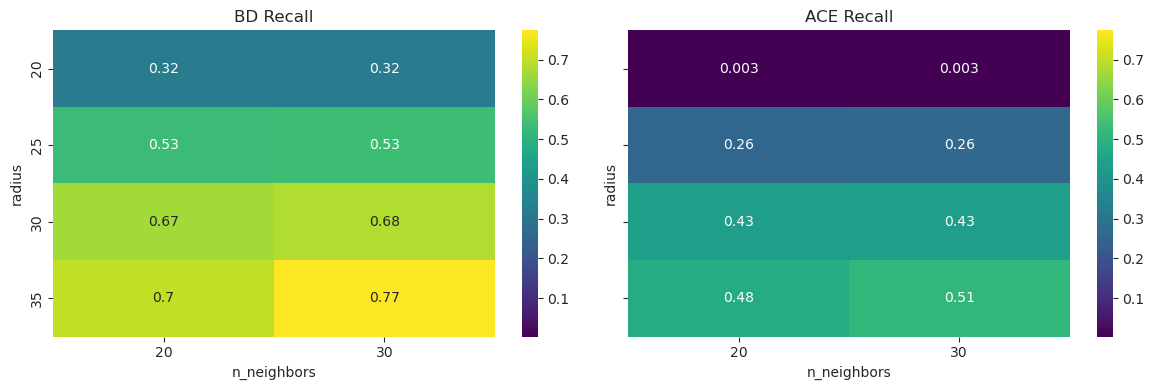

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# BD
pivot_bd = df_results.pivot_table(
    index="radius",
    columns="n_neighbors",
    values="bd_recall",
)

# ACE
pivot_ace = df_results.pivot_table(
    index="radius",
    columns="n_neighbors",
    values="ace_recall",
)

# use same color scale
vmin = min(pivot_bd.min().min(), pivot_ace.min().min())
vmax = max(pivot_bd.max().max(), pivot_ace.max().max())

sns.heatmap(pivot_bd, annot=True, cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[0])
axes[0].set_title("BD Recall")

sns.heatmap(pivot_ace, annot=True, cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_title("ACE Recall")

plt.tight_layout()
plt.show()

Purity

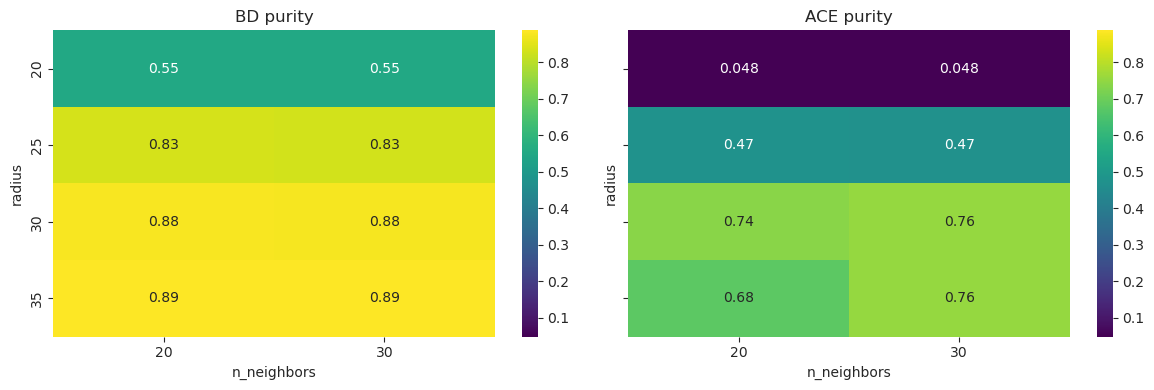

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# BD
pivot_bd = df_results.pivot_table(
    index="radius",
    columns="n_neighbors",
    values="bd_purity",
)

# ACE
pivot_ace = df_results.pivot_table(
    index="radius",
    columns="n_neighbors",
    values="ace_purity",
)

# use same color scale
vmin = min(pivot_bd.min().min(), pivot_ace.min().min())
vmax = max(pivot_bd.max().max(), pivot_ace.max().max())

sns.heatmap(pivot_bd, annot=True, cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[0])
axes[0].set_title("BD purity")

sns.heatmap(pivot_ace, annot=True, cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_title("ACE purity")

plt.tight_layout()
plt.show()

## Performance score
score = recall x purity
Keeps only rows where mean_neighbors is reasonable and frac_lt3_neighbors is low


In [22]:
df_summary = df_results.copy()

df_summary["bd_score"] = df_summary["bd_recall"] * df_summary["bd_purity"]
df_summary["ace_score"] = df_summary["ace_recall"] * df_summary["ace_purity"]

In [23]:
df_filtered = df_summary[
    (df_summary["mean_neighbors"] >= 10) &
    (df_summary["mean_neighbors"] <= 60) &
    (df_summary["frac_lt3_neighbors"] < 0.02)
].copy()

print("Remaining parameter combinations:", len(df_filtered))

Remaining parameter combinations: 12


In [24]:
best_bd = df_filtered.sort_values("bd_score", ascending=False).head(10)

display(
    best_bd[
        [
            "radius",
            "n_neighbors",
            "k_sim",
            "sketch_size",
            "bd_recall",
            "bd_purity",
            "bd_score",
            "mean_neighbors",
            "frac_lt3_neighbors",
        ]
    ]
)

,radius,n_neighbors,k_sim,sketch_size,bd_recall,bd_purity,bd_score,mean_neighbors,frac_lt3_neighbors
15,35,30,100,None,0.798736,0.865297,0.691143,26.339690,0.000040
14,35,30,50,None,0.748156,0.906190,0.677972,26.339690,0.000040
13,35,20,100,None,0.752898,0.866586,0.652451,19.402500,0.000040
11,30,30,100,None,0.717597,0.848070,0.608573,18.638393,0.000350
9,30,20,100,None,0.707060,0.860256,0.608253,17.073441,0.000350
12,35,20,50,None,0.643836,0.909226,0.585392,19.402500,0.000040
10,30,30,50,None,0.647524,0.902349,0.584293,18.638393,0.000350
8,30,20,50,None,0.625922,0.902050,0.564613,17.073441,0.000350
7,25,30,100,None,0.558483,0.825409,0.460977,11.003191,0.006532
5,25,20,100,None,0.555848,0.826019,0.459141,10.987726,0.006532


In [25]:
best_ace = df_filtered.sort_values("ace_score", ascending=False).head(10)

display(
    best_ace[
        [
            "radius",
            "n_neighbors",
            "k_sim",
            "sketch_size",
            "ace_recall",
            "ace_purity",
            "ace_score",
            "mean_neighbors",
            "frac_lt3_neighbors",
        ]
    ]
)

,radius,n_neighbors,k_sim,sketch_size,ace_recall,ace_purity,ace_score,mean_neighbors,frac_lt3_neighbors
14,35,30,50,None,0.493421,0.812274,0.400793,26.339690,0.000040
15,35,30,100,None,0.527961,0.700873,0.370033,26.339690,0.000040
9,30,20,100,None,0.469298,0.719933,0.337863,17.073441,0.000350
13,35,20,100,None,0.526316,0.635942,0.334706,19.402500,0.000040
11,30,30,100,None,0.462719,0.706276,0.326808,18.638393,0.000350
10,30,30,50,None,0.398026,0.805771,0.320718,18.638393,0.000350
12,35,20,50,None,0.427632,0.718894,0.307422,19.402500,0.000040
8,30,20,50,None,0.396930,0.755741,0.299976,17.073441,0.000350
7,25,30,100,None,0.324013,0.471668,0.152827,11.003191,0.006532
5,25,20,100,None,0.321820,0.469976,0.151248,10.987726,0.006532


In [26]:
df_filtered["combined_score"] = (
    df_filtered["bd_score"] + df_filtered["ace_score"]
) / 2

best_combined = df_filtered.sort_values("combined_score", ascending=False).head(10)

display(
    best_combined[
        [
            "radius",
            "n_neighbors",
            "k_sim",
            "sketch_size",
            "bd_score",
            "ace_score",
            "combined_score",
            "mean_neighbors",
            "frac_lt3_neighbors",
        ]
    ]
)

,radius,n_neighbors,k_sim,sketch_size,bd_score,ace_score,combined_score,mean_neighbors,frac_lt3_neighbors
14,35,30,50,None,0.677972,0.400793,0.539382,26.339690,0.000040
15,35,30,100,None,0.691143,0.370033,0.530588,26.339690,0.000040
13,35,20,100,None,0.652451,0.334706,0.493578,19.402500,0.000040
9,30,20,100,None,0.608253,0.337863,0.473058,17.073441,0.000350
11,30,30,100,None,0.608573,0.326808,0.467690,18.638393,0.000350
10,30,30,50,None,0.584293,0.320718,0.452505,18.638393,0.000350
12,35,20,50,None,0.585392,0.307422,0.446407,19.402500,0.000040
8,30,20,50,None,0.564613,0.299976,0.432295,17.073441,0.000350
7,25,30,100,None,0.460977,0.152827,0.306902,11.003191,0.006532
5,25,20,100,None,0.459141,0.151248,0.305194,10.987726,0.006532


### Mean_neighbors

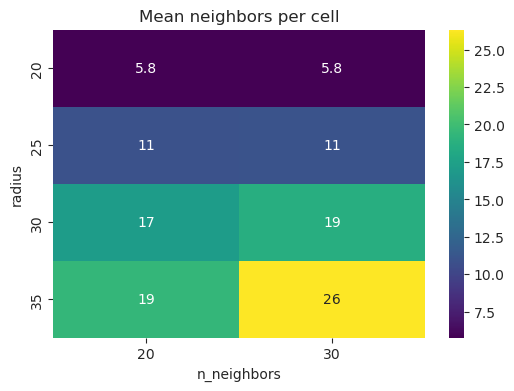

In [17]:
pivot_neighbors = df_results.pivot_table(
    index="radius",
    columns="n_neighbors",
    values="mean_neighbors",
)

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_neighbors, annot=True, cmap="viridis")
plt.title("Mean neighbors per cell")
plt.show()

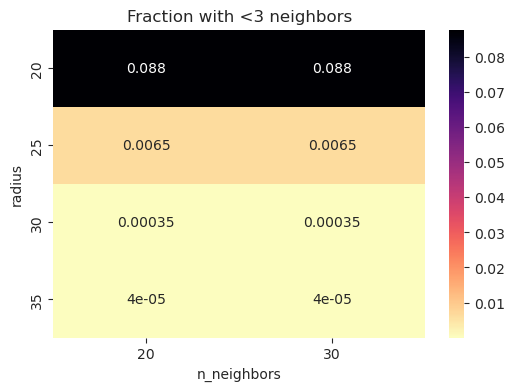

In [18]:
pivot_filter = df_results.pivot_table(
    index="radius",
    columns="n_neighbors",
    values="frac_lt3_neighbors",
)

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_filter, annot=True, cmap="magma_r")
plt.title("Fraction with <3 neighbors")
plt.show()

# Results - what I want to see:
High recall:
- BD recall close to 1
- ACE recall reasonably high

High purity: 0.6-0.8 is good

Reasonable neighborhood size: 
- mean_neighbors should not be too small (<5) or too large (>100)
- This tells us how large each local niche is:
    - too small = noisy niche vectors + unstable composition 
    - too large=over-smoothed, loses spatial resolution

Low filtering: frac_lt3_neighbors small (best to be < 0.02)
- Tells me how many cells were effectively unusable ie. the radius is too small or data too sparse

For this size niche then radius 35/ neighbors 30 seems best